In [45]:
# CELL 1 - RUN THIS FIRST
import tensorflow as tf
import gc
from tensorflow import keras

# Clear and configure GPU
keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✓ GPU configured")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
import cv2
import os
from tensorflow.keras import layers


✓ GPU configured


In [46]:
# ============================================================================
# CBAM ATTENTION MODULE IMPLEMENTATION
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        # Max pooling
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        # Combine and apply sigmoid
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling along channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # Max pooling along channel axis
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # Concatenate
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        
        # Apply convolution
        spatial_attention = self.conv(concat)
        
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module (CBAM)"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super(CBAM, self).get_config()
        return config

In [47]:
IMAGE_SIZE = 224
ORIGINAL_SIZE = 1024  # Original image dimensions
BASELINE_PATH = './output/emn_pneumo.keras'
CBAM_PATH = './output/pneumo_resnet50_cbam.keras'
CSV_PATH = './dataset_pneumothorax/pneumothorax_xy.csv'
IMAGE_DIR = './dataset_pneumothorax/images'

In [48]:
# ============================================================================
# LOAD DATA AND MODEL
# ============================================================================

df = pd.read_csv(CSV_PATH)
baseline_model = keras.models.load_model(BASELINE_PATH)
cbam_model = keras.models.load_model(CBAM_PATH, custom_objects={
        'CBAM': CBAM,
        'ChannelAttention': ChannelAttention,
        'SpatialAttention': SpatialAttention
    })
print(f"Loaded {len(df)} pneumothorax images with bounding boxes")
print(f"Scale factor: {IMAGE_SIZE}/{ORIGINAL_SIZE} = {IMAGE_SIZE/ORIGINAL_SIZE:.4f}")

Loaded 98 pneumothorax images with bounding boxes
Scale factor: 224/1024 = 0.2188


In [49]:
# ============================================================================
# LOAD AND PREPROCESS IMAGE FUNCTION
# ============================================================================
def load_and_preprocess_image(image_path):
    """Load and preprocess image for prediction."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    
    img = tf.keras.applications.resnet_v2.preprocess_input(img)
    img_array = tf.expand_dims(img, 0)
    
    return img_array

CONFIDENCE SCORE COMPARISON: Baseline vs CBAM Models (With Labels)
Image                Baseline   CBAM       Diff     Ground Truth Baseline Correctness CBAM Correctness
----------------------------------------------------------------------------------------------------
00005448_014.png     0.9254     0.9597     0.0342   1            ✓                  ✓               
00018253_029.png     0.1192     0.0903     -0.0288  0            ✓                  ✓               
00002090_004.png     0.4392     0.6161     0.1769   1            ✗                  ✓               
00011223_000.png     0.1257     0.0715     -0.0542  0            ✓                  ✓               
00008180_006.png     0.5771     0.6911     0.1140   1            ✓                  ✓               
00011391_044.png     0.2644     0.1612     -0.1032  0            ✓                  ✓               


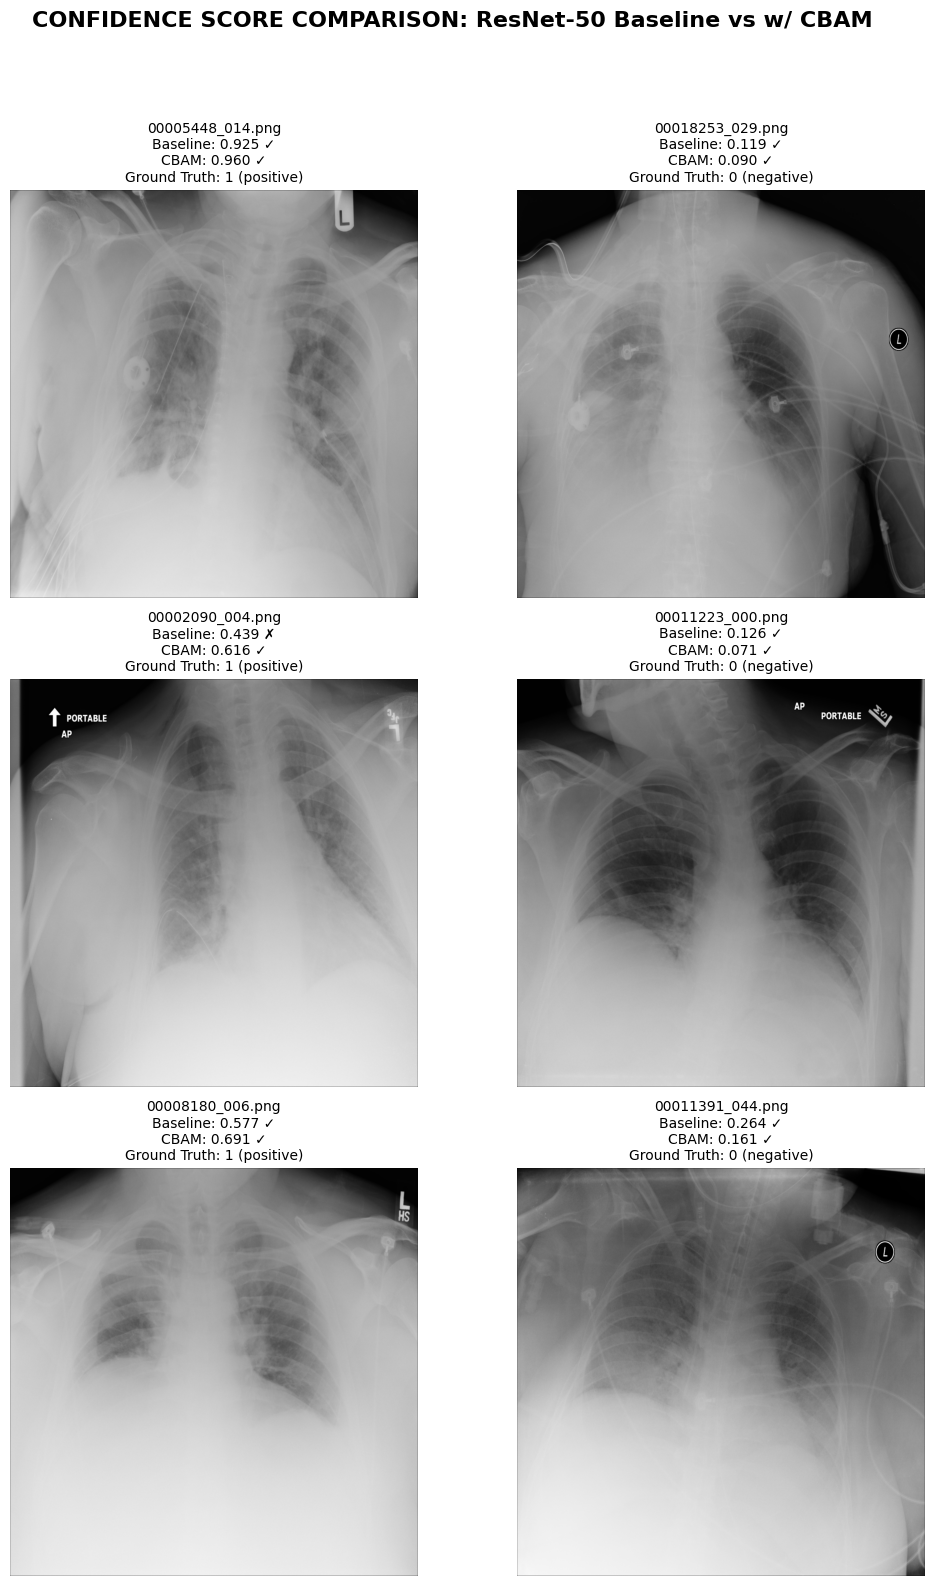

Notes:
- Confidence scores are sigmoid outputs (0-1, higher = more likely pneumothorax).
- Diff = CBAM - Baseline.
- Ground Truth: 1 = pneumothorax, 0 = no pneumothorax.
- Correctness: 'Correct' if prediction matches ground truth (threshold 0.5).
- Ensure CSV has 'Image_Index' and 'Binary_Label' columns.


In [80]:
# ============================================================================
# PREDICT AND COMPARE CONFIDENCE SCORES ON SPECIFIC IMAGES (WITH IMAGES AND LABELS)
# ============================================================================
import matplotlib.pyplot as plt

# Load the pneumothorax CSV for labels
LABEL_CSV_PATH = './dataset_pneumothorax/pneumothorax.csv'
label_df = pd.read_csv(LABEL_CSV_PATH)
label_column = 'Binary_Label'  

images_to_test = [
    '00005448_014.png',
    '00018253_029.png',
    '00002090_004.png',
    '00011223_000.png',
    '00008180_006.png',
    '00011391_044.png'
]

# Prepare data for visualization
results = []
fig, axes = plt.subplots(3, 2, figsize=(12, 18))  # 3x2 grid for 6 images
axes = axes.flatten()

print(f"{'='*100}")
print("CONFIDENCE SCORE COMPARISON: Baseline vs CBAM Models (With Labels)")
print(f"{'='*100}")
print(f"{'Image':<20} {'Baseline':<10} {'CBAM':<10} {'Diff':<8} {'Ground Truth':<12} {'Baseline Correctness':<18} {'CBAM Correctness':<16}")
print("-" * 100)

for i, img_name in enumerate(images_to_test):
    image_path = os.path.join(IMAGE_DIR, img_name)
    
    try:
        img_array = load_and_preprocess_image(image_path)
        
        # Get predictions
        baseline_pred = baseline_model.predict(img_array, verbose=0)[0][0]
        cbam_pred = cbam_model.predict(img_array, verbose=0)[0][0]
        diff = cbam_pred - baseline_pred
        
        # Get ground truth label
        gt_row = label_df[label_df['Image_Index'] == img_name]
        if gt_row.empty:
            gt_label = 'N/A'
            baseline_correct = 'N/A'
            cbam_correct = 'N/A'
        else:
            gt_label = int(gt_row[label_column].iloc[0])
            baseline_correct = '✓' if (baseline_pred > 0.5) == gt_label else '✗'
            cbam_correct = '✓' if (cbam_pred > 0.5) == gt_label else '✗'
        
        # Store for visualization
        img_display = tf.io.read_file(image_path)
        img_display = tf.image.decode_png(img_display, channels=3).numpy()
        results.append((img_display, baseline_pred, cbam_pred, gt_label, baseline_correct, cbam_correct))
        
        print(f"{img_name:<20} {baseline_pred:<10.4f} {cbam_pred:<10.4f} {diff:<8.4f} {str(gt_label):<12} {baseline_correct:<18} {cbam_correct:<16}")
    
    except FileNotFoundError:
        print(f"{img_name:<20} {'N/A':<10} {'N/A':<10} {'N/A':<8} {'N/A':<12} {'N/A':<18} {'N/A':<16} (Image not found)")
        results.append((None, None, None, None, None, None))  # Placeholder for missing image

# Visualization
for i, (img, baseline_pred, cbam_pred, gt_label, baseline_correct, cbam_correct) in enumerate(results):
    ax = axes[i]
    if img is not None:
        gt_text = '1 (positive)' if gt_label == 1 else '0 (negative)' if gt_label == 0 else str(gt_label)
        ax.imshow(img)
        ax.set_title(f'{images_to_test[i]}\nBaseline: {baseline_pred:.3f} {baseline_correct}\nCBAM: {cbam_pred:.3f} {cbam_correct}\nGround Truth: {gt_text}', fontsize=10)
    else:
        ax.text(0.5, 0.5, 'Image Not Found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('CONFIDENCE SCORE COMPARISON: ResNet-50 Baseline vs w/ CBAM', fontsize=16, fontweight='bold')
plt.subplots_adjust()
plt.show()

print(f"{'='*100}")
print("Notes:")
print("- Confidence scores are sigmoid outputs (0-1, higher = more likely pneumothorax).")
print("- Diff = CBAM - Baseline.")
print("- Ground Truth: 1 = pneumothorax, 0 = no pneumothorax.")
print("- Correctness: 'Correct' if prediction matches ground truth (threshold 0.5).")
print("- Ensure CSV has 'Image_Index' and 'Binary_Label' columns.")